<a href="https://colab.research.google.com/github/KoraRiko/joke_generator/blob/main/AI_Joke_Metrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# Installing libraries
!pip install openai sentence-transformers transformers torch scikit-learn nltk sacrebleu pandas tqdm
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [16]:
import os
import openai
import pandas as pd
from tqdm import tqdm
from itertools import combinations
import numpy as np

# setting OpenAI
from google.colab import userdata
#Runtime -> "User-provided secrets" -> secret OPENAI_API_KEY
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
KEYWORDS = ["girlfriend", "birth", "letter", "princess", "sheep", "board", "hipsters"]

NUM_SAMPLES_PER_KEYWORD = 10  # How many jokes are generated per word

Fine tuned

In [3]:
from openai import OpenAI

def generate_joke(keyword, model="ft:gpt-3.5-turbo-0125:korariko::DQ1ft67K", temperature=0.5):

    SYSTEM_PROMPT = """You are a professional comedy writer specializing in clever wordplay and safe-but-edgy humor. Apply the Benign Violation principle — break an expectation or norm, but keep it safe and clever."""

    USER_PROMPT = f"Generate a short, clever joke about: {keyword}. Joke must visible include the word '{keyword}'."
    try:
        client = OpenAI()  # automatically reads OPENAI_API_KEY from environment
        response = client.chat.completions.create(
            model=model,
            messages=[
              {"role": "system", "content": SYSTEM_PROMPT},
              {"role": "user", "content": USER_PROMPT},
            ],
            temperature=temperature,
            max_tokens=80
        )
        joke = response.choices[0].message.content.strip()  # .content, not ['content']
        return joke
    except Exception as e:
        print(f"Generation error in keyword '{keyword}': {e}")
        return None
#Генирация
all_jokes = []
for keyword in tqdm(KEYWORDS, desc="Joke Generation"):
    for i in range(NUM_SAMPLES_PER_KEYWORD):
        joke = generate_joke(keyword)
        if joke:
            all_jokes.append({"keyword": keyword, "joke": joke})
        else:
            all_jokes.append({"keyword": keyword, "joke": "[ERROR]"})

pd.set_option('display.max_colwidth', None)
df = pd.DataFrame(all_jokes)
print("\nJoke Generated", len(df))
display(df)

Joke Generation: 100%|██████████| 7/7 [01:35<00:00, 13.69s/it]


Joke Generated 70


,keyword,joke
0,girlfriend,"I was having sex with my girlfriend when her boyfriend came home. Man, was he pissed."
1,girlfriend,My girlfriend told me to stop playing Wonderwall I said maybe.
2,girlfriend,"My girlfriend broke up with me because I'm a compulsive liar. I told her, ""No, I'm not."""
3,girlfriend,My girlfriend told me to take the spider out instead of killing it... We went and had some drinks. Cool guy. Wants to be a web developer.
4,girlfriend,"My girlfriend and I have a long distance relationship. Which is pretty much the same as a regular relationship, except I can't see her."
...,...,...
65,hipsters,"How many hipsters does it take to screw in a lightbulb? It's a really obscure number, you've probably never heard of it."
66,hipsters,"How many hipsters does it take to screw in a light bulb? It's a pretty obscure number, you've probably never heard of it."
67,hipsters,How many hipsters does it take to screw in a lightbulb? It's an obscure number. You've probably never heard of it.
68,hipsters,"How many hipsters does it take to screw in a lightbulb? It's a really obscure number, I don't know if you've heard of it."


Without fine tune

In [17]:
from openai import OpenAI

def generate_joke(keyword, model="gpt-3.5-turbo", temperature=0.5):

    SYSTEM_PROMPT = """You are a professional comedy writer specializing in clever wordplay and safe-but-edgy humor. Apply the Benign Violation principle — break an expectation or norm, but keep it safe and clever."""

    USER_PROMPT = f"Generate a short, clever joke about: {keyword}. Joke must visible include the word '{keyword}'."
    try:
        client = OpenAI()  # automatically reads OPENAI_API_KEY from environment
        response = client.chat.completions.create(
            model=model,
            messages=[
              {"role": "system", "content": SYSTEM_PROMPT},
              {"role": "user", "content": USER_PROMPT},
            ],
            temperature=temperature,
            max_tokens=80
        )
        joke = response.choices[0].message.content.strip()  # .content, not ['content']
        return joke
    except Exception as e:
        print(f"Generation error in keyword  '{keyword}': {e}")
        return None
#Generation
all_jokes = []
for keyword in tqdm(KEYWORDS, desc="Joke Generation"):
    for i in range(NUM_SAMPLES_PER_KEYWORD):
        joke = generate_joke(keyword)
        if joke:
            all_jokes.append({"keyword": keyword, "joke": joke})
        else:
            all_jokes.append({"keyword": keyword, "joke": "[ERROR]"})

pd.set_option('display.max_colwidth', None)
df = pd.DataFrame(all_jokes)
print("\nJoke generated:", len(df))
display(df)

Joke Generation: 100%|██████████| 7/7 [00:56<00:00,  8.04s/it]


Joke generated: 70


,keyword,joke
0,girlfriend,Why did the girlfriend break up with the calendar? Because she couldn't handle all the dates!
1,girlfriend,Why did the math book break up with the novel? \nBecause it had too many problems and couldn't handle the story problems! Just like my girlfriend with her endless shopping problems!
2,girlfriend,Why did the boyfriend bring a ladder to his girlfriend's house? He heard she likes taking their relationship to the next level!
3,girlfriend,Why did the girlfriend break up with the calendar? Because she couldn't handle all the dates!
4,girlfriend,Why did the girlfriend break up with the calendar? Because she couldn't handle all the dates!
...,...,...
65,hipsters,Why did the hipster bring a ladder to the bar? \n\nHe heard the drinks were on a higher level than mainstream ones.
66,hipsters,Why did the hipster bring a ladder to the bar? \n\nBecause he heard the drinks were on a higher level of irony.
67,hipsters,Why did the hipster refuse to play hide and seek? \n\nBecause good luck finding them when they're always in a state of ironic obscurity.
68,hipsters,Why did the hipster bring a ladder to the bar? \n\nHe heard the drinks were on a higher level of irony.


In [18]:
# Installing libraries
!pip install sacrebleu

Metrics initialization

In [19]:
from sentence_transformers import SentenceTransformer
from transformers import pipeline, GPT2LMHeadModel, GPT2Tokenizer
from sklearn.metrics.pairwise import cosine_similarity
from sacrebleu.metrics import BLEU
import torch

# Semantic model
sem_model = SentenceTransformer('all-MiniLM-L6-v2')

# Humor classifier (public model for humour)
humor_pipe = pipeline(
    "text-classification",
    model="likhithasapu/humour-detection-mBert",
    truncation=True,
    max_length=128
)

# Perplexity (GPT-2)
ppl_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
ppl_model = GPT2LMHeadModel.from_pretrained("gpt2")
ppl_model.eval()

# BLEU scorer
bleu_scorer = BLEU(effective_order=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Metrics functions

In [20]:
def compute_semantic_distance(keyword, joke):
    emb_kw = sem_model.encode([keyword])
    emb_joke = sem_model.encode([joke])
    sim = cosine_similarity(emb_kw, emb_joke)[0][0]
    return float(1 - sim)

def compute_perplexity(text):
    inputs = ppl_tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = ppl_model(**inputs, labels=inputs["input_ids"])
        return float(torch.exp(outputs.loss).item())

def compute_humor_score(joke):
    try:
        result = humor_pipe(joke)[0]
        if result['label'] == 'HUMOR':
            return float(result['score'])
        else:
            return float(1 - result['score'])
    except:
        return 0.0

Main computation of joke quality metrics and composite scoring

In [21]:
from tqdm import tqdm
tqdm.pandas()

valid_df = df[df['joke'] != "[ERROR]"].copy()

valid_df['semantic_distance'] = valid_df.progress_apply(
    lambda row: compute_semantic_distance(row['keyword'], row['joke']), axis=1
)
valid_df['perplexity'] = valid_df['joke'].progress_apply(compute_perplexity)
valid_df['humor_score'] = valid_df['joke'].progress_apply(compute_humor_score)

# Composite score (normalize and average)
for col in ['semantic_distance', 'perplexity', 'humor_score']:
    valid_df[col] = pd.to_numeric(valid_df[col], errors='coerce')
    valid_df[col] = valid_df[col].fillna(valid_df[col].median())
    valid_df[f"{col}_norm"] = (valid_df[col] - valid_df[col].min()) / (valid_df[col].max() - valid_df[col].min() + 1e-8)

# Invert perplexity: high surprisal = good
valid_df['perplexity_norm'] = 1 - valid_df['perplexity_norm']
valid_df['semantic_distance_norm'] = 1 - valid_df['semantic_distance_norm']

valid_df['composite_score'] = valid_df[['semantic_distance_norm', 'perplexity_norm', 'humor_score_norm']].mean(axis=1)

# Merge it back with the original df (to preserve the order)
df = df.merge(valid_df[['keyword', 'joke', 'semantic_distance', 'perplexity', 'humor_score', 'composite_score']],
              on=['keyword', 'joke'], how='left')


100%|██████████| 70/70 [00:21<00:00,  3.26it/s]


Displaying the top 5 highest-ranked jokes.

In [22]:
print("\nTop 5 jokes by composite_score:")
pd.set_option('display.max_colwidth', None)
display(df.nlargest(5, 'composite_score')[['keyword', 'joke', 'composite_score']])


Top 5 jokes by composite_score:


,keyword,joke,composite_score
64,sheep,Why did the sheep go to the hair salon? To get a baa-baa-baa-rber cut!,0.784871
25,birth,Why did the baby bring a ladder to the birth? Because it wanted to come into the world step by step!,0.779890
36,letter,Why did the envelope break up with the stamp? It just couldn't handle the pressure of commitment... to deliver that love letter!,0.775912
31,birth,"Why did the baby bring a ladder to the birth? Because it wanted to be born under a ""rising"" sign!",0.740872
55,sheep,Why did the sheep go to the hair salon? To get a baa-baa-baa-d haircut!,0.687526


Scatter plot visualizing the relationship between semantic distance and humor score across different keywords.

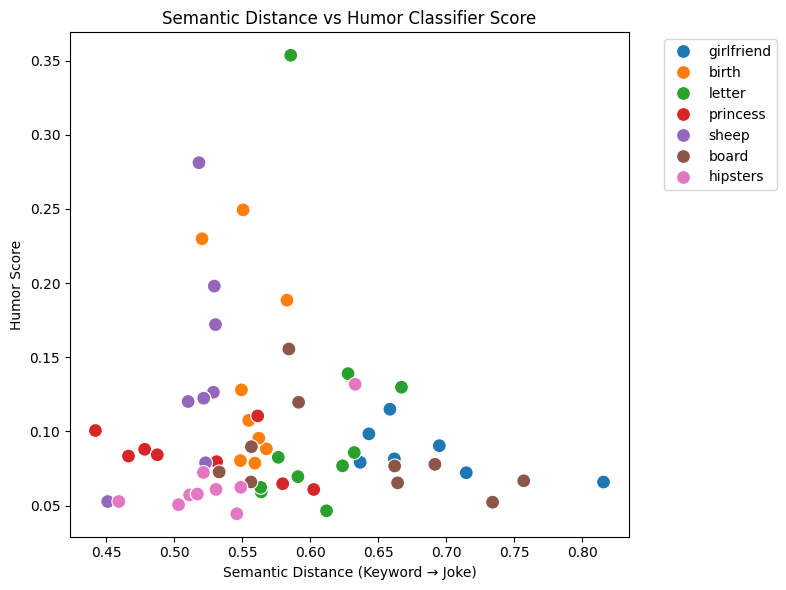

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='semantic_distance', y='humor_score', hue='keyword', s=100)
plt.title('Semantic Distance vs Humor Classifier Score')
plt.xlabel('Semantic Distance (Keyword → Joke)')
plt.ylabel('Humor Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Visualization of the Composite Quality Score Distribution

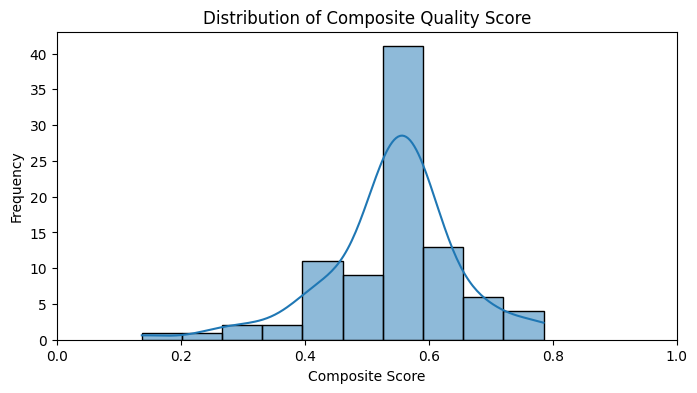

In [24]:
plt.figure(figsize=(8, 4))
sns.histplot(df['composite_score'].dropna(), bins=10, kde=True)
plt.title('Distribution of Composite Quality Score')
plt.xlabel('Composite Score')
plt.ylabel('Frequency')
plt.xlim(0, 1)
plt.show()

Joke Quality Distribution by Keyword

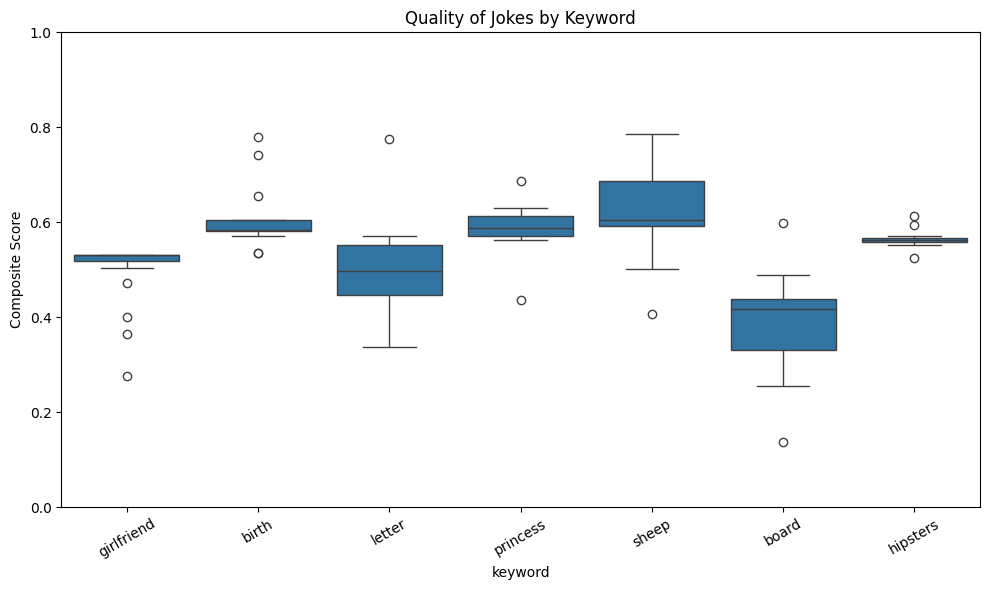

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='keyword', y='composite_score')
plt.xticks(rotation=30)
plt.title('Quality of Jokes by Keyword')
plt.ylabel('Composite Score')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Metrics Correlation Heatmap

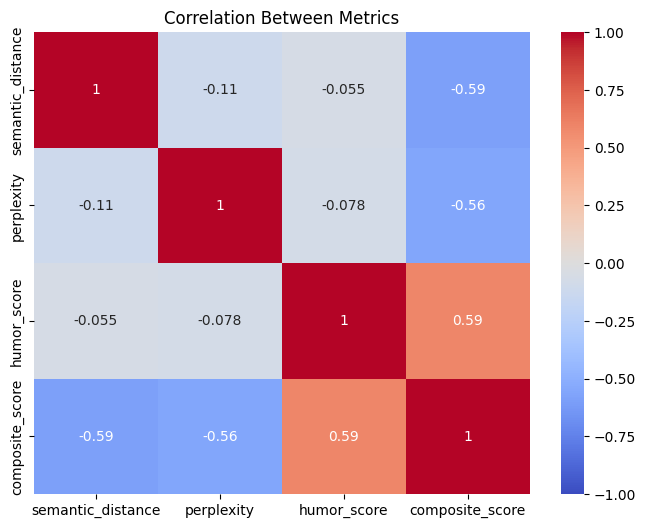

In [26]:
corr = df[['semantic_distance', 'perplexity', 'humor_score', 'composite_score']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Between Metrics')
plt.show()